[t=      1] eps=15.2238  H1_max=0.8242  H2_max=0.0000
[t=    834] eps=11.6211  H1_max=0.6214  H2_max=0.0000
[t=   1667] eps=8.8280  H1_max=0.5531  H2_max=0.0000
[t=   2500] eps=7.6940  H1_max=0.4635  H2_max=0.0000
[t=   3333] eps=5.9245  H1_max=0.3129  H2_max=0.0000
[t=   4166] eps=4.5162  H1_max=0.2398  H2_max=0.0000
[t=   5000] eps=3.3597  H1_max=0.2246  H2_max=0.0000
[t=   5833] eps=3.2015  H1_max=0.2178  H2_max=0.0000
[t=   6666] eps=2.8379  H1_max=0.1787  H2_max=0.0000
[t=   7500] eps=2.2165  H1_max=0.1498  H2_max=0.0000
[t=   8333] eps=1.5929  H1_max=0.1036  H2_max=0.0000
[t=   9166] eps=2.6319  H1_max=0.1643  H2_max=0.0000
[t=  10000] eps=1.8976  H1_max=0.1165  H2_max=0.0000
[t=  10833] eps=1.4270  H1_max=0.0939  H2_max=0.0000
[t=  11666] eps=0.9798  H1_max=0.0659  H2_max=0.0000
[t=  12500] eps=2.2192  H1_max=0.1336  H2_max=0.0000
[t=  13333] eps=1.6769  H1_max=0.1080  H2_max=0.0000
[t=  14166] eps=1.2839  H1_max=0.0777  H2_max=0.0000
[t=  15000] eps=0.9373  H1_max=0.0702  H2_ma

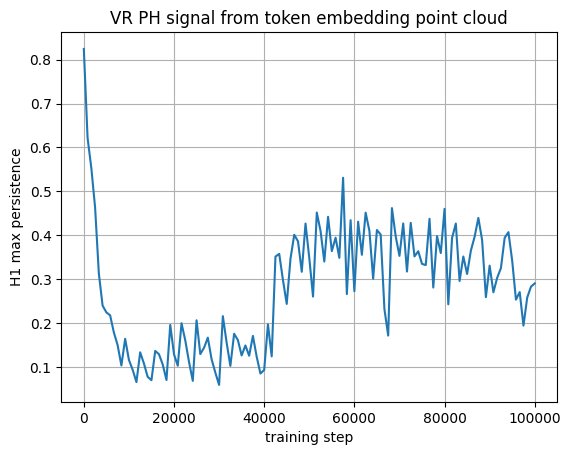

In [3]:
import os, json, csv
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, List, Dict, Any

import gudhi as gd


# ---------------------------
# Load spline representation
# ---------------------------
class TokEmbSpline:
    def __init__(self, t: np.ndarray, c: np.ndarray):
        self.t = np.asarray(t, dtype=np.float64)
        self.c = np.asarray(c, dtype=np.float32)
        if self.t.ndim != 1:
            raise ValueError("t must be 1D")
        if self.c.shape[0] != 4:
            raise ValueError(f"c[0] must be 4, got {self.c.shape}")
        if self.c.shape[1] != self.t.size - 1:
            raise ValueError(f"c.shape[1] must be T-1; got {self.c.shape}, T={self.t.size}")
        if self.c.shape[2:] != (113, 128):
            raise ValueError(f"Expected (113,128), got {self.c.shape[2:]}")
        if not np.all(np.diff(self.t) > 0):
            raise ValueError("t must be strictly increasing")

    @staticmethod
    def load(npz_path: str) -> "TokEmbSpline":
        data = np.load(npz_path)
        return TokEmbSpline(data["t"], data["c"])

    def eval(self, tau: float) -> np.ndarray:
        t = self.t
        c = self.c
        k = int(np.searchsorted(t, tau, side="right") - 1)
        k = int(np.clip(k, 0, t.size - 2))
        dx = np.float32(tau - t[k])
        a0 = c[0, k]
        a1 = c[1, k]
        a2 = c[2, k]
        a3 = c[3, k]
        return (a0 + dx * (a1 + dx * (a2 + dx * a3))).astype(np.float32, copy=False)


def load_manifest_steps(manifest_path: str) -> List[int]:
    if not os.path.exists(manifest_path):
        return []
    steps = []
    with open(manifest_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                obj = json.loads(line)
                if "step" in obj:
                    steps.append(int(obj["step"]))
    return sorted(set(steps))


def preprocess_points(E: np.ndarray, *, center=True, row_normalize=False) -> np.ndarray:
    X = E.astype(np.float64, copy=True)
    if center:
        X -= X.mean(axis=0, keepdims=True)
    if row_normalize:
        n = np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
        X /= n
    return X


def _pairwise_dists_upper_triangle(X: np.ndarray) -> np.ndarray:
    # p=113 -> ~6328 distances, cheap
    # compute full pairwise via Gram trick
    G = X @ X.T
    sq = np.clip(np.diag(G)[:, None] + np.diag(G)[None, :] - 2 * G, 0.0, None)
    D = np.sqrt(sq)
    iu = np.triu_indices(D.shape[0], k=1)
    return D[iu]


def choose_max_edge_length(X: np.ndarray, quantile: float = 0.2, cap: Optional[float] = None) -> float:
    d = _pairwise_dists_upper_triangle(X)
    eps = float(np.quantile(d, quantile))
    if cap is not None:
        eps = min(eps, float(cap))
    # 防止 eps 太小导致几乎没 1-simplex
    return max(eps, 1e-8)


def rips_diagrams(
    X: np.ndarray,
    *,
    max_dim: int = 2,
    max_edge_length: float,
    min_persistence: float = 0.0,
):
    rc = gd.RipsComplex(points=X, max_edge_length=max_edge_length)
    st = rc.create_simplex_tree(max_dimension=max_dim)
    st.compute_persistence(min_persistence=min_persistence)

    dgm0 = st.persistence_intervals_in_dimension(0)
    dgm1 = st.persistence_intervals_in_dimension(1)
    dgm2 = st.persistence_intervals_in_dimension(2) if max_dim >= 2 else np.zeros((0,2))
    return dgm0, dgm1, dgm2


def pers_stats(dgm: np.ndarray) -> Dict[str, Any]:
    if dgm.size == 0:
        return {"count": 0, "max_pers": 0.0, "total_pers": 0.0}
    pers = dgm[:, 1] - dgm[:, 0]
    finite = np.isfinite(pers)
    pers = pers[finite]
    if pers.size == 0:
        return {"count": int(dgm.shape[0]), "max_pers": 0.0, "total_pers": 0.0}
    return {
        "count": int(dgm.shape[0]),
        "max_pers": float(np.max(pers)),
        "total_pers": float(np.sum(pers)),
    }


def run_over_time(
    out_dir: str,
    spline_npz: str,
    *,
    times: Optional[List[float]] = None,
    use_manifest_if_times_none: bool = True,
    time_stride: int = 5,
    # IMPORTANT: spline interpolation usefulness
    interp_per_interval: int = 0,  # 0 = only snapshot steps; >0 = add points between snapshots
    # point preprocessing
    center: bool = True,
    row_normalize: bool = False,
    # ε selection
    eps_quantile: float = 0.2,
    eps_cap: Optional[float] = None,
    # PH params
    max_dim: int = 2,
    min_persistence: float = 0.0,
    # outputs
    save_some_diagrams: bool = True,
    diagram_save_every: int = 20,  # save diagrams occasionally (expensive in storage)
    make_plot: bool = True,
):
    os.makedirs(out_dir, exist_ok=True)
    spline = TokEmbSpline.load(spline_npz)

    if times is None:
        if use_manifest_if_times_none:
            msteps = load_manifest_steps(os.path.join(out_dir, "manifest.jsonl"))
            times = [float(s) for s in (msteps if msteps else spline.t.tolist())]
        else:
            times = [float(s) for s in spline.t.tolist()]

    # subsample snapshot times first
    base_times = times[::max(1, int(time_stride))]

    # optionally add interpolated times inside each interval
    if interp_per_interval > 0:
        dense_times = []
        for a, b in zip(base_times[:-1], base_times[1:]):
            dense_times.append(a)
            for r in range(1, interp_per_interval + 1):
                dense_times.append(a + (b - a) * (r / (interp_per_interval + 1)))
        dense_times.append(base_times[-1])
        times = dense_times
    else:
        times = base_times

    rows = []
    diag_dir = os.path.join(out_dir, "tda_rips_diagrams")
    if save_some_diagrams:
        os.makedirs(diag_dir, exist_ok=True)

    for idx, tau in enumerate(times):
        E = spline.eval(tau)
        X = preprocess_points(E, center=center, row_normalize=row_normalize)

        # auto pick ε scale from distances
        eps = choose_max_edge_length(X, quantile=eps_quantile, cap=eps_cap)

        d0, d1, d2 = rips_diagrams(
            X, max_dim=max_dim, max_edge_length=eps, min_persistence=min_persistence
        )

        s1 = pers_stats(d1)
        s2 = pers_stats(d2)

        met = {
            "step": float(tau),
            "eps": float(eps),
            "h1_count": s1["count"],
            "h1_max_pers": s1["max_pers"],
            "h1_total_pers": s1["total_pers"],
            "h2_count": s2["count"],
            "h2_max_pers": s2["max_pers"],
            "h2_total_pers": s2["total_pers"],
        }
        rows.append(met)

        print(f"[t={int(tau):>7d}] eps={eps:.4f}  H1_max={met['h1_max_pers']:.4f}  H2_max={met['h2_max_pers']:.4f}")

        # Save diagrams occasionally (for barcode inspection)
        if save_some_diagrams and (idx % max(1, diagram_save_every) == 0):
            np.savez_compressed(
                os.path.join(diag_dir, f"step_{int(tau):07d}.npz"),
                step=float(tau), eps=float(eps), dgm0=d0, dgm1=d1, dgm2=d2
            )

    # Save metrics
    save_npz = os.path.join(out_dir, "tda_rips_tok_emb_metrics.npz")
    np.savez_compressed(
        save_npz,
        step=np.array([r["step"] for r in rows], dtype=np.float64),
        eps=np.array([r["eps"] for r in rows], dtype=np.float64),
        h1_max_pers=np.array([r["h1_max_pers"] for r in rows], dtype=np.float64),
        h1_total_pers=np.array([r["h1_total_pers"] for r in rows], dtype=np.float64),
        h1_count=np.array([r["h1_count"] for r in rows], dtype=np.int32),
        h2_max_pers=np.array([r["h2_max_pers"] for r in rows], dtype=np.float64),
        h2_total_pers=np.array([r["h2_total_pers"] for r in rows], dtype=np.float64),
        h2_count=np.array([r["h2_count"] for r in rows], dtype=np.int32),
    )
    print(f"[OK] saved: {save_npz}")

    save_csv = os.path.join(out_dir, "tda_rips_tok_emb_metrics.csv")
    with open(save_csv, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader()
        w.writerows(rows)
    print(f"[OK] saved: {save_csv}")

    if make_plot:
        steps = np.array([r["step"] for r in rows], dtype=np.float64)
        h1max = np.array([r["h1_max_pers"] for r in rows], dtype=np.float64)

        plt.figure()
        plt.plot(steps, h1max)
        plt.xlabel("training step")
        plt.ylabel("H1 max persistence")
        plt.title("VR PH signal from token embedding point cloud")
        plt.grid(True)
        fig_path = os.path.join(out_dir, "tda_rips_tok_emb_H1max.png")
        plt.savefig(fig_path, dpi=200)
        print(f"[OK] saved: {fig_path}")

    return rows


# ---------------------------
# OPTIONAL: plot barcode from a saved diagram file
# ---------------------------
def plot_barcode_from_saved(diag_npz: str, dim: int = 1, topk: int = 50):
    d = np.load(diag_npz)
    step = float(d["step"])
    eps = float(d["eps"])
    dgm = d[f"dgm{dim}"]
    if dgm.size == 0:
        print(f"No features in H{dim} at step {int(step)}")
        return

    pers = dgm[:, 1] - dgm[:, 0]
    finite = np.isfinite(pers)
    dgm = dgm[finite]
    pers = pers[finite]

    order = np.argsort(-pers)[:topk]
    dgm = dgm[order]
    pers = pers[order]

    plt.figure(figsize=(7, 4))
    for i, (b, de) in enumerate(dgm):
        plt.plot([b, de], [i, i])
    plt.xlabel("ε (distance threshold)")
    plt.ylabel(f"top {topk} features")
    plt.title(f"Barcode H{dim} @ step={int(step)} (eps_cap used={eps:.4f})")
    plt.grid(True)
    plt.show()


if __name__ == "__main__":
    OUT_DIR = "./runs/modadd_grokking_03"
    SPLINE_NPZ = os.path.join(OUT_DIR, "tda_tok_emb_spline.npz")

    run_over_time(
        out_dir=OUT_DIR,
        spline_npz=SPLINE_NPZ,
        times=None,
        use_manifest_if_times_none=True,
        time_stride=5,
        interp_per_interval=2,      # <- 关键：插 2 个点，真正用到 spline
        center=True,
        row_normalize=False,
        eps_quantile=0.20,          # <- 距离分布 20% 分位作为 ε 上限
        eps_cap=None,               # 也可以设一个硬上限，比如 10.0
        max_dim=2,
        min_persistence=0.0,
        save_some_diagrams=True,
        diagram_save_every=20,
        make_plot=True,
    )

    # Example: after running, pick one saved file to inspect barcode:
    # plot_barcode_from_saved("./runs/modadd_grokking_03/tda_rips_diagrams/step_00040000.npz", dim=1, topk=50)
